In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import matplotlib.patches as patches
import time
import pandas as pd

# Functions

In [2]:
def dneff_w(width, a, b):
    '''Function to model the variation of effective index with waveguide width.

    Inputs:
    - width: array of waveguide widths (um)
    - a, b: fitting parameters

    Outputs:
    - dneff: array of effective index variations corresponding to the input widths
    '''
    # Variation of effective index with waveguide width
    width_0 = 1.0
    dneff = a*(width - width_0)**2 + b*(width - width_0)
    return dneff

def neff_wl(wavelength, a, b, c):
    '''Function to model the variation of effective index with wavelength.

    Inputs:
    - wavelength: array of wavelengths (nm)
    - a, b, c: fitting parameters

    Outputs:
    - neff: array of effective indices corresponding to the input wavelengths
    '''
    # Variation of effective index with wavelength
    wl_0 = 1550
    neff = a - b*(wavelength - wl_0) - c*(wavelength - wl_0)**2
    return neff

def neff_model(wavelength_train, width_train, dneff_train, neff_train, width_test, wavelength_test, neff_valid):
    '''Function to model the effective index variation with wavelength and waveguide width.

    Inputs:
    - wavelength_train: array of training wavelengths (nm)
    - width_train: array of training waveguide widths (um)
    - dneff_train: array of training effective index variations
    - neff_train: array of training effective indices
    - width_test: array of test waveguide widths (um)
    - wavelength_test: array of test wavelengths (nm)
    - neff_valid: array of validation effective indices

    Outputs:
    - mse: mean squared error between predicted and validation effective indices
    - neff_test2: array of predicted effective indices for the test data
    - popt_w: optimized parameters for the effective index as a function of waveguide width
    - popt_wl: optimized parameters for the effective index as a function of wavelength
    '''
    width_0 = 1.0
    wl_0 = 1550

    p0_w = [0, 0]
    limits_w = ([-np.inf, -np.inf], [np.inf, np.inf])
    popt_w, pcov_w = curve_fit(dneff_w, width_train, dneff_train, bounds = limits_w, p0=p0_w, maxfev = int(1e5))

    p0_wl = [1.54, 0, 0]
    limits_wl = ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
    popt_wl, pcov_wl = curve_fit(neff_wl, wavelength_train, neff_train, bounds = limits_wl, p0=p0_wl, maxfev = int(1e5))

    neff_test = neff_wl(wavelength_train, *popt_wl) + dneff_w(width_test, *popt_w)
    mse = np.mean((neff_valid - neff_test)**2)

    neff_test2 = neff_wl(wavelength_test, *popt_wl) + dneff_w(width_test, *popt_w)

    # print(f'neff (λ [nm]) = {popt_wl[0]:.5f} - {popt_wl[1]:.5f}*(λ - {wl_0}) - ({popt_wl[2]:.5e}*(λ - {wl_0})^2)')
    # print(f'Δneff (w [μm]) = {popt_w[0]:.5f}*(w - {width_0})^2 + {popt_w[1]:.5f}*(w - {width_0})')

    return mse, neff_test2, popt_w, popt_wl

def open_file_modesolver(file_path, mode=0):
    ''' Function to open and read mode solver data from a file.

    Inputs:
    - file_path: path to the file containing mode solver data
    - mode: mode number to extract (default is 0, TE0 mode)

    Outputs:
    - wavelength: array of wavelengths
    - n_eff: array of effective indices
    '''
    with open(file_path, 'r') as f:
        first_line = f.readline()

    wl, index, neff = np.loadtxt(file_path, skiprows=1, usecols=(0, 1, 2), dtype=complex, unpack=True)
    filter = (index == mode)
    
    # Load wavelength and effective index
    wavelength, n_eff = wl[filter].real, neff[filter].real

    return wavelength, n_eff

def C_matrix(wavelength, neff, dz):
    '''Function to calculate the propagation matrix for a given wavelength, effective index, and step size.

    Inputs:
    - wavelength: wavelength of light (m)
    - neff: effective index of the waveguide
    - dz: step size along the waveguide (m)
    '''
    C = np.zeros((2, 2), dtype=complex)
    phase = 2*np.pi*neff/wavelength * dz
    C[0,0] = np.exp(1j * phase)
    C[1,1] = np.exp(-1j * phase)
    return C

def I_matrix(neff_1, neff_2):
    '''Function to calculate the interface matrix for two effective indices.
    
    Inputs:
    - neff_1: effective index of the first waveguide section
    - neff_2: effective index of the second waveguide section
    '''
    I = np.zeros((2, 2))
    I[0,0] = neff_1 + neff_2
    I[1,1] = I[0,0]
    I[0,1] = neff_2 - neff_1
    I[1,0] = I[0,1]
    I = (1/(2*np.sqrt(neff_1 * neff_2)))*I
    return I

def Bragg_grating(wavelength, w_array, dz, N, popt_wl, popt_w):
    '''Function to calculate the transfer matrix for a Bragg grating over a range of wavelengths and waveguide widths.

    Inputs:
    - wavelength: array of wavelengths to calculate the transfer matrix for (m)
    - w_array: array of waveguide widths along the grating (m)
    - dz: step size along the grating (m)
    - N: number of steps along the grating
    - popt_wl: optimized parameters for the effective index as a function of wavelength
    - popt_w: optimized parameters for the effective index as a function of waveguide width

    Outputs:
    - M_T: list of transfer matrices for each wavelength
    '''
    M_T = []

    for wl in wavelength:
        M = np.eye(2, dtype=complex)
        neff = []

        for w in w_array:
            n = neff_wl(wl*1e9, *popt_wl) + dneff_w(w, *popt_w)
            neff.append(n)
        
        for i in range(N-1):
            I = I_matrix(neff[i], neff[i+1])
            C = C_matrix(wl, neff[i+1], dz)
            M @= I @ C
        
        M_T.append(M)

    return M_T

def uniform_grating(period, dwidth_2, N, duty, dL):
    '''Function to generate a uniform grating with specified parameters.

    Inputs:
    - period: grating period (m)
    - dwidth_2: corrugation of the second section of the grating (m)
    - N: number of periods in the grating
    - duty: duty cycle of the grating (fraction of the period occupied by the first section)
    - dL: length of the grating (m)

    Outputs:
    - z_real: array of positions along the grating (m)
    - dw_real_p: array of width variations for the positive section of the grating (um)
    - dw_real_n: array of width variations for the negative section of the grating (um)
    '''
    resolution = 500*N # Number of points to represent the grating
    L = period*N
    
    z_real = np.linspace(0, L, resolution)
    dw_real_p = np.where((z_real % period) < (period*duty), 0.0, dwidth_2) # Width variations for the positive section
    dw_real_n = -np.where(((z_real - dL) % period) < (period*duty), 0.0, dwidth_2) # Width variations for the negative section
    return z_real, np.array(dw_real_p), np.array(dw_real_n)

def grating_geometry(z_real, w_real_p, w_real_n, M):
    '''Function to calculate the mean width of the grating in M steps along the z direction.
    
    Inputs:
    - z_real: array of positions along the grating (m)
    - w_real_p: array of width variations for the positive section of the grating (um)
    - w_real_n: array of width variations for the negative section of the grating (um)
    - M: number of steps to divide the grating into
    
    Outputs:
    - z_edges: array of edges of the M steps along the z direction (m)
    - w_mean_p: array of mean widths for the positive section of the grating in each step (um)
    - w_mean_n: array of mean widths for the negative section of the grating in each step (um)
    '''
    # Calculate the mean width of the grating in M steps along the z direction
    L = max(z_real)

    z_edges = np.linspace(0, L, M + 1) 
    w_mean_p = []
    w_mean_n = []
    z_center = []

    for i in range(M):
        z_min = z_edges[i]
        z_max = z_edges[i+1]
        
        mask = (z_real >= z_min) & (z_real < z_max)
        
        step_mean_width_p = np.mean(w_real_p[mask])
        w_mean_p.append(step_mean_width_p)

        step_mean_width_n = np.mean(w_real_n[mask])
        w_mean_n.append(step_mean_width_n)
        
        z_center.append((z_min + z_max) / 2)

    return z_edges, np.array(w_mean_p), np.array(w_mean_n)

def prefab_grating(z_real, sigma, dw_real_p, dw_real_n, scale_factor):
    '''Function to apply a Gaussian filter to the grating width variations and scale by a loss factor.
    
    Inputs:
    - z_real: array of positions along the grating (m)
    - sigma: standard deviation of the Gaussian filter (m)
    - dw_real_p: array of width variations for the positive section of the grating (um)
    - dw_real_n: array of width variations for the negative section of the grating (um)
    - scale_factor: scaling factor to account for losses in the grating
    
    Outputs:
    - dw_fab_p: array of filtered and scaled width variations for the positive section of the grating (um)
    - dw_fab_n: array of filtered and scaled width variations for the negative section of the grating (um)
    '''
    dz = z_real[1] - z_real[0]

    z_kernel = np.arange(-4*sigma, 4*sigma, dz)
    gaussian_kernel = (1/(sigma*np.sqrt(2*np.pi)))*np.exp(-z_kernel**2/(2*sigma**2))
    gaussian_kernel /= np.sum(gaussian_kernel)

    dw_fab_p = np.convolve(dw_real_p, gaussian_kernel, mode='same')
    dw_fab_n = np.convolve(dw_real_n, gaussian_kernel, mode='same')

    dw_fab_p *= scale_factor
    dw_fab_n *= scale_factor

    return dw_fab_p, dw_fab_n

def find_minima(power, wavelength, threshold, separation):
    '''Function to find minima in the power spectrum.

    Inputs:
    - power: array of power values
    - wavelength: array of wavelength values
    - threshold: minimum prominence of the peaks
    - separation: minimum distance between peaks

    Outputs:
    - indices: array of indices of the found minima
    '''
    power_inverted = -power

    # Calculate average step size in wavelength and convert separation from nm to number of points based on average step size
    avg_step = np.mean(np.diff(wavelength)) 
    dist_points = int(separation/avg_step) 

    indices, properties = find_peaks(power_inverted, prominence=threshold, distance=dist_points)

    return indices

def find_minima_sides(wavelength, transmittance, distance):
    idx_min = np.argmin(transmittance)

    left_trans = transmittance[:idx_min]
    left_wl = wavelength[:idx_min]

    left_peaks, _ = find_peaks(left_trans, distance=distance)
    if len(left_peaks) > 0:
        idx_peak_left = left_peaks[-1]
        wl_left = left_wl[idx_peak_left]
        trans_left = left_trans[idx_peak_left]
    else:
        wl_left, trans_left, idx_peak_left = None, None, None

    right_trans = transmittance[idx_min:]

    right_peaks, _ = find_peaks(right_trans, distance=distance)
    if len(right_peaks) > 0:
        idx_peak_right = right_peaks[0] + idx_min
        wl_right = wavelength[idx_peak_right]
        trans_right = transmittance[idx_peak_right]
    else:
        wl_right, trans_right, idx_peak_right = None, None, None

    return [idx_peak_left, idx_peak_right], [wl_left, wl_right]

def Bragg_grating_mod(wavelength, w_array, dz, N, popt_wl, popt_w, delta_n):
    '''Function to calculate the transfer matrix for a Bragg grating over a range of wavelengths and waveguide widths.

    Inputs:
    - wavelength: array of wavelengths to calculate the transfer matrix for (m)
    - w_array: array of waveguide widths along the grating (m)
    - dz: step size along the grating (m)
    - N: number of steps along the grating
    - popt_wl: optimized parameters for the effective index as a function of wavelength
    - popt_w: optimized parameters for the effective index as a function of waveguide width
    - delta_n: overall experimental refractive index shift

    Outputs:
    - M_T: list of transfer matrices for each wavelength
    '''
    M_T = []

    for wl in wavelength:
        M = np.eye(2, dtype=complex)
        neff = []

        for w in w_array:
            n = neff_wl(wl*1e9, *popt_wl) + dneff_w(w, *popt_w) + delta_n
            neff.append(n)
        
        for i in range(N-1):
            I = I_matrix(neff[i], neff[i+1])
            C = C_matrix(wl, neff[i+1], dz)
            M @= I @ C
        
        M_T.append(M)

    return M_T

# Initialization

In [3]:
material = 'BCB'
wl_center = 1550
window_size = 5

# U1 design parameters
N_u1 = 1000
wl_u1 = (np.arange(8)-3)*10 + wl_center

# U2 design parameters
N_u2 = 2000
wl_u2 = (np.arange(6)-2)*10 + wl_center

# U3 design parameters
N_u3 = 4000
wl_u3 = (np.arange(4)-2)*10 + wl_center

sigma = 60*1e-9 # Lithography defocus (nm)
scale_factor = 0.9 # Height scale factor due to fabrication imperfections

width_0 = 1.0 # Nominal Width of the waveguide (um)
width = np.round(width_0 + np.arange(0, 9)*0.05, 2) # Waveguide width list (um)
dwidth = (width - width_0)/2 # Corrugation list (um)

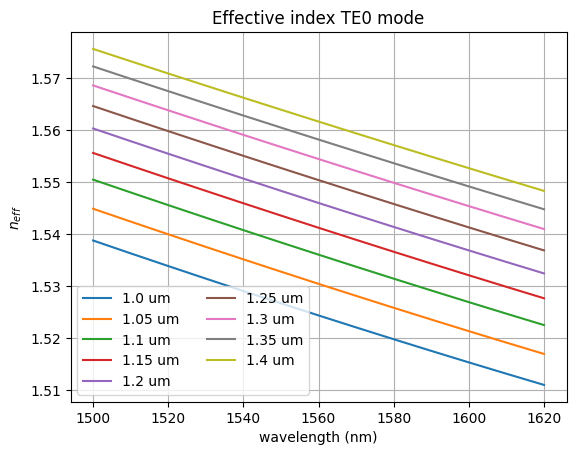

In [4]:
# Extract Effective Indices from Modesolver results
dneff = []
n_eff = []

file_path = f"/home/arjoa/UPVfab/upvfab-design-tools/results/{material}/1.0um/modesolver_results_1.0um.txt"
wavelength_0, neff_0 = open_file_modesolver(file_path)

for w in width:
    file_path = f"/home/arjoa/UPVfab/upvfab-design-tools/results/{material}/{w}um/modesolver_results_{w}um.txt"
    wavelength, neff = open_file_modesolver(file_path)

    dneff.append(np.mean(neff - neff_0))
    n_eff.append(neff)
    plt.plot(wavelength, neff, label=f'{w} um')

plt.title('Effective index TE0 mode')
plt.xlabel('wavelength (nm)')
plt.ylabel(r'$n_{eff}$')
plt.grid()
plt.legend(ncols=2)
plt.show()

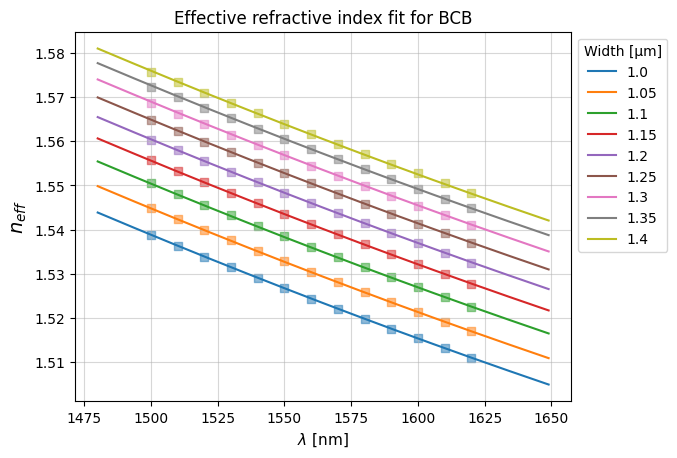

In [5]:
# Create and effective index model for the waveguides as a funcion of wavelength and width
dneff_train = dneff
neff_train = n_eff[0]
wavelength_train = wavelength
width_train = width

wavelength_test = np.arange(1480, 1650, 1)

for i, w in enumerate(width):
    width_test = w
    neff_valid = n_eff[i]

    mse, neff_test, popt_w, popt_wl = neff_model(wavelength_train, width_train, dneff_train, neff_train, width_test, wavelength_test, neff_valid)

    fit, = plt.plot(wavelength_test, neff_test, label = f'{width_test}')
    plt.scatter(wavelength, neff_valid, color = fit.get_color(), alpha=0.5, marker='s')
    
plt.title(fr'Effective refractive index fit for {material}')
plt.xlabel(r'$\lambda$ [nm]', fontsize=11)
plt.ylabel(r'$n_{eff}$', fontsize=14)
plt.grid(which='both', alpha=0.5)
plt.legend(fontsize = 10, title='Width [μm]', bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

U1 parameters 

λ   = [1520 1530 1540 1550 1560 1570 1580 1590] (nm)
ΔW  = [ 25.  50.  75. 100. 125. 150. 175. 200.] (nm)
Λ   = [494.5100947  497.64142118 500.82363834 504.05772417 507.34468885
 510.68557587 514.08146312 517.53346404] (nm)


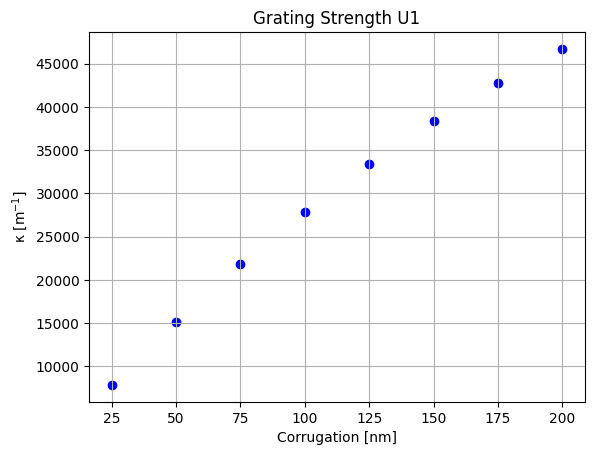

In [6]:
# Obtain the grating period for each U1 Bragg grating
period_array_u1 = []
n1_array = []
n2_array = []
n_avg_u1 = []

i = 1 # Start with a corrugation of 25 nm
for bragg_wl in wl_u1:
    neff_1 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_0, *popt_w)
    neff_2 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width[i], *popt_w)

    n_avg = (neff_1 + neff_2)/2
    period = bragg_wl/(2*n_avg)

    n1_array.append(float(neff_1))
    n2_array.append(float(neff_2))
    n_avg_u1.append(float(n_avg))
    period_array_u1.append(float(period*1e-3))
    i+=1

print('U1 parameters \n')
print(f'λ   = {wl_u1} (nm)')
print(f'ΔW  = {(width[1:] - width_0)/2*1e3} (nm)')
print(f'Λ   = {np.array(period_array_u1)*1e3} (nm)')

# Grating Strength Estimation
delta_n = np.array(n2_array) - np.array(n1_array)
kappa_u1 = 2*delta_n/((np.array(n1_array)  + np.array(n2_array))*np.array(period_array_u1)*1e-6)
plt.scatter((width[1:] - width_0)/2*1e3, kappa_u1, color='b')

plt.title('Grating Strength U1')
plt.ylabel(r'κ [m$^{-1}$]')
plt.xlabel('Corrugation [nm]')
plt.grid()
plt.show()

U2 parameters 

λ   = [1530 1540 1550 1560 1570 1580] (nm)
ΔW  = [ 25.  50.  75. 100. 125. 150.] (nm)
Λ   = [498.54817136 501.67392744 504.8509589  508.08024049 511.36277939
 514.69961629] (nm)


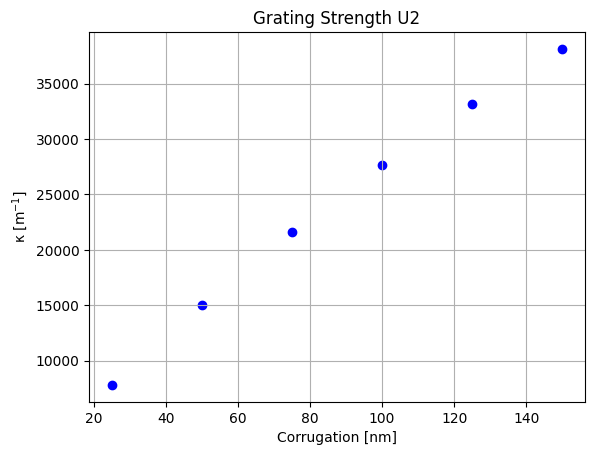

In [7]:
# Obtain the grating period for each U2 Bragg grating
period_array_u2 = []
n1_array = []
n2_array = []
n_avg_u2 = []

i = 1 # Start with a corrugation of 25 nm
for bragg_wl in wl_u2:
    neff_1 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_0, *popt_w)
    neff_2 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width[i], *popt_w)

    n_avg = (neff_1 + neff_2)/2
    period = bragg_wl/(2*n_avg)

    n1_array.append(float(neff_1))
    n2_array.append(float(neff_2))
    n_avg_u2.append(float(n_avg))
    period_array_u2.append(float(period*1e-3))
    i+=1

print('U2 parameters \n')
print(f'λ   = {wl_u2} (nm)')
print(f'ΔW  = {(width[1:7] - width_0)/2*1e3} (nm)')
print(f'Λ   = {np.array(period_array_u2)*1e3} (nm)')

# Grating Strength
delta_n = np.array(n2_array) - np.array(n1_array)
kappa_u2 = 2*delta_n/(wl_u2*1e-9)
plt.scatter((width[1:7] - width_0)/2*1e3, kappa_u2, color='b')

plt.title('Grating Strength U2')
plt.ylabel(r'κ [m$^{-1}$]')
plt.xlabel('Corrugation [nm]')
plt.grid()
plt.show()

U3 parameters 

λ   = [1530 1540 1550 1560] (nm)
ΔW  = [ 50.  75. 100. 125.] (nm)
Λ   = [497.64142118 500.82363834 504.05772417 507.34468885] (nm)


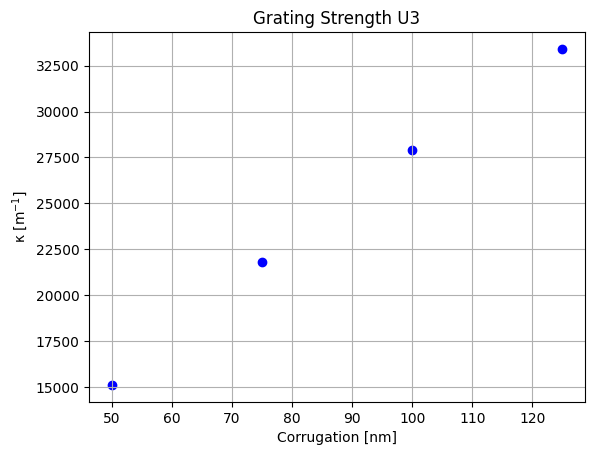

In [8]:
# Obtain the grating period for each U3 Bragg grating
period_array_u3 = []
n1_array = []
n2_array = []
n_avg_u3 = []

i = 2 # Start with a corrugation of 50 nm
for bragg_wl in wl_u3:
    neff_1 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_0, *popt_w)
    neff_2 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width[i], *popt_w)

    n_avg = (neff_1 + neff_2)/2
    period = bragg_wl/(2*n_avg)

    n1_array.append(float(neff_1))
    n2_array.append(float(neff_2))
    n_avg_u3.append(float(n_avg))
    period_array_u3.append(float(period*1e-3))
    i+=1

print('U3 parameters \n')
print(f'λ   = {wl_u3} (nm)')
print(f'ΔW  = {(width[2:6] - width_0)/2*1e3} (nm)')
print(f'Λ   = {np.array(period_array_u3)*1e3} (nm)')

# Grating Strength
delta_n = np.array(n2_array) - np.array(n1_array)
kappa_u3 = 2*delta_n/(wl_u3*1e-9)
plt.scatter((width[2:6] - width_0)/2*1e3, kappa_u3, color='b')

plt.title('Grating Strength U3')
plt.ylabel(r'κ [m$^{-1}$]')
plt.xlabel('Corrugation [nm]')
plt.grid()
plt.show()

# Parameters

In [9]:
# Sigma
sigma_array = np.arange(0, 251, 50) * 1e-9 + 1.0e-11
n_u1 = 15  
M_u1_fab = int(n_u1 * (2 * N_u1))
scale_factor = 1.0
delta_n = -0.016

T_sigma = []

for i in range(len(period_array_u1)):
    wavelength_test = np.arange(wl_u1[i]-window_size, wl_u1[i]+window_size, 0.125)*1e-9
    L = N_u1 * period_array_u1[i] * 1e-6
    dz = L / M_u1_fab

    z_real, dw_real_p, dw_real_n = uniform_grating(period_array_u1[i] * 1e-6, dwidth[i + 1], N_u1, duty=0.5, dL=0)
    z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_u1_fab)

    T_sigma_u1 = []            

    for sigma in sigma_array:
        t_inicio = time.perf_counter()  

        dw_fab_p, dw_fab_n = prefab_grating(z_real, sigma, dw_real_p, dw_real_n, scale_factor)
        z_edges_fab, dw_mean_fab_p, dw_mean_fab_n = grating_geometry(z_real, dw_fab_p, dw_fab_n, M_u1_fab)
        w_mean_fab = dw_mean_fab_p - dw_mean_fab_n + width_0

        
        M_wl = Bragg_grating_mod(wavelength_test, w_mean_fab, dz, M_u1_fab, popt_wl, popt_w, delta_n)
        
        T_buff = []
        for j in range(len(wavelength_test)):
            T_buff.append(1/(np.abs(M_wl[j][0, 0])**2))
        
        t_fin = time.perf_counter()  # Marca el final
        duracion = t_fin - t_inicio
        
        T_sigma_u1.append(T_buff)
    
        print(f"Grating: {i+1}, sigma = {sigma:.2e} -> Execution Time: {duracion:.4f} seconds")

    T_sigma.append(T_sigma_u1)
    

Grating: 1, sigma = 1.00e-11 -> Execution Time: 22.1541 seconds
Grating: 1, sigma = 5.00e-08 -> Execution Time: 22.1315 seconds
Grating: 1, sigma = 1.00e-07 -> Execution Time: 22.2557 seconds
Grating: 1, sigma = 1.50e-07 -> Execution Time: 22.3978 seconds


KeyboardInterrupt: 

In [ ]:
# Scale Factor
scale_array = np.arange(1, 0.3, -0.1)

sigma = 1.0e-10
n_u1 = 1  
M_u1_fab = int(n_u1 * (2 * N_u1))

T_scale = []
for i in range(len(period_array_u1)):
    wavelength_test = np.arange(wl_u1[i]-window_size, wl_u1[i]+window_size, 0.125)*1e-9
    L = N_u1 * period_array_u1[i] * 1e-6
    dz = L / M_u1_fab

    z_real, dw_real_p, dw_real_n = uniform_grating(period_array_u1[i] * 1e-6, dwidth[i + 1], N_u1, duty=0.5, dL=0)
    z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_u1_fab)

    T_scale_u1 = []           

    for scale_factor in scale_array:
        t_inicio = time.perf_counter()  

        dw_fab_p, dw_fab_n = prefab_grating(z_real, sigma, dw_real_p, dw_real_n, scale_factor)
        z_edges_fab, dw_mean_fab_p, dw_mean_fab_n = grating_geometry(z_real, dw_fab_p, dw_fab_n, M_u1_fab)
        w_mean_fab = dw_mean_fab_p - dw_mean_fab_n + width_0

        M_wl = Bragg_grating_mod(wavelength_test, w_mean_fab, dz, M_u1_fab, popt_wl, popt_w, delta_n)
        
        T_buff = []
        for j in range(len(wavelength_test)):
            T_buff.append(1/(np.abs(M_wl[j][0, 0])**2))
        
        t_fin = time.perf_counter()  # Marca el final
        duracion = t_fin - t_inicio
        
        T_scale_u1.append(T_buff)
    
        print(f"Grating {i+1}, Scale Factor = {scale_factor:.1f} -> Execution Time: {duracion:.4f} seconds")

    T_scale.append(T_scale_u1)

Grating 1, Scale Factor = 1.0 -> Execution Time: 1.0626 seconds
Grating 1, Scale Factor = 0.9 -> Execution Time: 1.0936 seconds
Grating 1, Scale Factor = 0.8 -> Execution Time: 1.0371 seconds
Grating 1, Scale Factor = 0.7 -> Execution Time: 1.0391 seconds
Grating 1, Scale Factor = 0.6 -> Execution Time: 1.0288 seconds
Grating 1, Scale Factor = 0.5 -> Execution Time: 1.0357 seconds
Grating 1, Scale Factor = 0.4 -> Execution Time: 1.0341 seconds
Grating 1, Scale Factor = 0.3 -> Execution Time: 1.0483 seconds
Grating 2, Scale Factor = 1.0 -> Execution Time: 1.0046 seconds
Grating 2, Scale Factor = 0.9 -> Execution Time: 1.0227 seconds
Grating 2, Scale Factor = 0.8 -> Execution Time: 1.0246 seconds
Grating 2, Scale Factor = 0.7 -> Execution Time: 1.0350 seconds
Grating 2, Scale Factor = 0.6 -> Execution Time: 1.0183 seconds
Grating 2, Scale Factor = 0.5 -> Execution Time: 1.0696 seconds
Grating 2, Scale Factor = 0.4 -> Execution Time: 1.0679 seconds
Grating 2, Scale Factor = 0.3 -> Executi

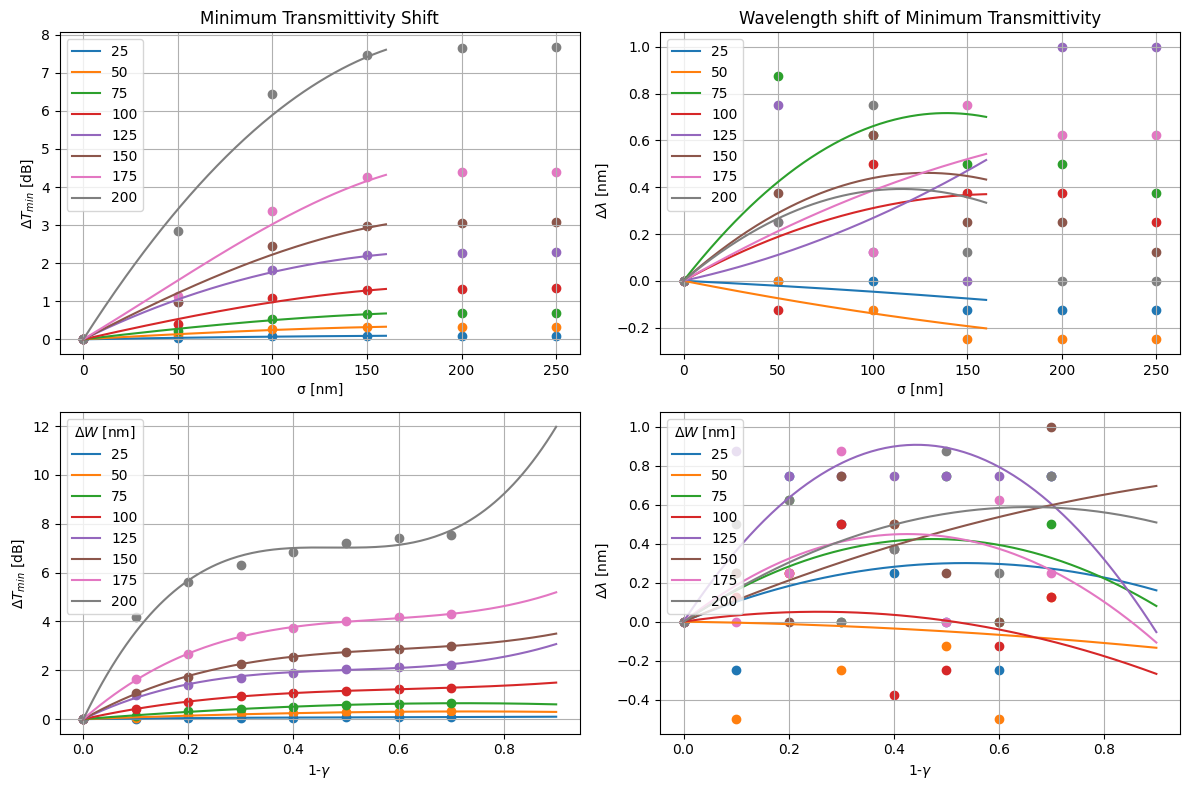

In [ ]:
def dT_sigma(sigma, a, b, c):
    return a*sigma**3 + b*sigma**2 + c*sigma

def dwl_sigma(sigma, a, b):
    return a*sigma**2 + b*sigma

def dT_scale(scale, a, b, c):
    return a*scale**3 + b*scale**2 + c*scale

def dwl_scale(scale, a, b, c):
    return a*scale**2 + b*scale + c*scale

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

parameters_dT_scale = []
parameters_dwl_scale = []
parameters_dT_sigma = []
parameters_dwl_sigma = []

scale_test = np.linspace(0.1, 1.0, 200)
sigma_test = np.linspace(0, 160, 200)*1e-9

for j in range(len(period_array_u1)):
    wavelength_test = np.arange(wl_u1[j]-window_size, wl_u1[j]+window_size, 0.125)*1e-9

    ## Scale factor analysis
    T_scale_u1 = T_scale[j]
    T_min_u1_scale = [min(10*np.log10(np.array(T_scale_u1[i]))) for i in range(len(scale_array))]
    wl_min_u1_scale = [wavelength_test[np.argmin(T_scale_u1[i])]*1e9 for i in range(len(scale_array))]

    p0_scale = [0, 0, 0]
    limits_scale = ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
    popt_scale, pcov_scale = curve_fit(dT_scale, 1-scale_array, T_min_u1_scale - T_min_u1_scale[0], bounds=limits_scale, p0=p0_scale, maxfev = int(1e4))

    p0_wl_scale = [0, 0, 0]
    limits_wl_scale = ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
    popt_wl_scale, pcov_wl_scale = curve_fit(dwl_scale, 1-scale_array, wl_min_u1_scale - wl_min_u1_scale[0], bounds=limits_wl_scale, p0=p0_wl_scale, maxfev = int(1e4))

    parameters_dT_scale.append(popt_scale)
    parameters_dwl_scale.append(popt_wl_scale)

    line = axs[1, 0].scatter(1-scale_array, T_min_u1_scale - T_min_u1_scale[0], marker='o')
    axs[1, 0].plot(1-scale_test, dT_scale(1-scale_test, *popt_scale), color=line.get_facecolor()[0], label=f'{dwidth[j+1]*1e3:.0f}')

    line = axs[1, 1].scatter(1-scale_array, wl_min_u1_scale - wl_min_u1_scale[0], marker='o')
    axs[1, 1].plot(1-scale_test, dwl_scale(1-scale_test, *popt_wl_scale), color=line.get_facecolor()[0], label=f'{dwidth[j+1]*1e3:.0f}')

    ## Sigma analysis
    T_sigma_u1 = T_sigma[j]
    T_min_u1_sigma = [min(10*np.log10(np.array(T_sigma_u1[i]))) for i in range(len(sigma_array))]
    wl_min_u1_sigma = [wavelength_test[np.argmin(T_sigma_u1[i])]*1e9 for i in range(len(sigma_array))]

    p0_sigma = [0, 0, 0]
    limits_sigma = ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
    popt_sigma, pcov_sigma = curve_fit(dT_sigma, sigma_array*1e9, T_min_u1_sigma - T_min_u1_sigma[0], bounds=limits_sigma, p0=p0_sigma, maxfev = int(1e4))

    p0_wl_sigma = [0, 0]
    limits_wl_sigma = ([-np.inf, -np.inf], [np.inf, np.inf])
    popt_wl_sigma, pcov_wl_sigma = curve_fit(dwl_sigma, sigma_array*1e9, wl_min_u1_sigma - wl_min_u1_sigma[0], bounds=limits_wl_sigma, p0=p0_wl_sigma, maxfev = int(1e4))

    parameters_dT_sigma.append(popt_sigma)
    parameters_dwl_sigma.append(popt_wl_sigma)

    line = axs[0, 0].scatter(sigma_array*1e9, T_min_u1_sigma - T_min_u1_sigma[0], marker='o')
    axs[0, 0].plot(sigma_test*1e9, dT_sigma(sigma_test*1e9, *popt_sigma), color=line.get_facecolor()[0], label=f'{dwidth[j+1]*1e3:.0f}')

    line = axs[0, 1].scatter(sigma_array*1e9, wl_min_u1_sigma - wl_min_u1_sigma[0], marker='o')
    axs[0, 1].plot(sigma_test*1e9, dwl_sigma(sigma_test*1e9, *popt_wl_sigma), color=line.get_facecolor()[0], label=f'{dwidth[j+1]*1e3:.0f}')

axs[0, 0].set_title('Minimum Transmittivity Shift')
axs[0, 0].set_ylabel(r'$\Delta T_{min}$ [dB]')
axs[0, 0].set_xlabel('σ [nm]')
axs[0, 0].legend()
axs[0, 0].grid()

axs[0, 1].set_title('Wavelength shift of Minimum Transmittivity')
axs[0, 1].set_ylabel(r' $\Delta \lambda$ [nm]')
axs[0, 1].set_xlabel('σ [nm]')
axs[0, 1].legend()
axs[0, 1].grid()

axs[1, 0].set_ylabel(r'$\Delta T_{min}$ [dB]')
axs[1, 0].set_xlabel(r'1-$\gamma$')
axs[1, 0].legend(title=r'$\Delta W$ [nm]')
axs[1, 0].grid()

axs[1, 1].set_ylabel(r' $\Delta \lambda$ [nm]')
axs[1, 1].set_xlabel(r'1-$\gamma$')
axs[1, 1].legend(title=r'$\Delta W$ [nm]')
axs[1, 1].grid()
plt.tight_layout()
plt.show()

In [ ]:
def imprimir_tabla(array_datos, titulo=""):
    print(f"=== {titulo} ===")

    # 1. Crear el DataFrame con columnas dinamicas según la cantidad de parámetros
    num_cols = len(array_datos[0])
    col_names = ["a", "b", "c"][:num_cols]
    df = pd.DataFrame(array_datos, columns=col_names)

    # Si el array solo trae 2 elementos (a, b), nos aseguramos de añadir 'c' con 0.0
    if "c" not in df.columns:
        df["c"] = 0.0

    # 2. Agregar la columna ΔW [nm] a partir de dwidth (convertido e integerizado)
    dw_vals = (dwidth[1 : len(array_datos) + 1] * 1e3).round(0).astype(int)
    df.insert(0, "ΔW [nm]", dw_vals)

    # 3. Imprimir directamente ajustando los decimales sin usar .style
    print(df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print("\n")


print("Model: ΔT=a*(1- γ)^3 + b*(1- γ)^2 + c*(1- γ)")
imprimir_tabla(parameters_dT_scale, "dT Loss")

print("Model: Δλ=a*(1- γ)^3 + b*(1- γ)^2 + c*(1- γ)")
imprimir_tabla(parameters_dwl_scale, "dwl Loss")

print("Model: ΔT=a*(σ[nm])^3 + b*(σ[nm])^2 + c*(σ[nm])")
imprimir_tabla(parameters_dT_sigma, "dT Sigma")

print("Model: Δλ=a*(σ[nm])^2 + b*(σ[nm])")
imprimir_tabla(parameters_dwl_sigma, "dwl Sigma")

Model: ΔT=a*(1- γ)^3 + b*(1- γ)^2 + c*(1- γ)
=== dT Loss ===
 ΔW [nm]       a        b       c
      25  0.1196  -0.2678  0.2526
      50 -0.1193  -0.4086  0.7914
      75 -0.2597  -0.8750  1.6689
     100  3.7598  -6.8986  4.8252
     125 12.7276 -19.3423 10.5144
     150 10.2672 -18.3630 12.1009
     175 18.0472 -30.7978 18.8712
     200 65.7268 -93.8806 44.5577


Model: Δλ=a*(1- γ)^3 + b*(1- γ)^2 + c*(1- γ)
=== dwl Loss ===
 ΔW [nm]       a        b        c
      25 -1.0504 -59.1995  60.3234
      50 -0.1225 -59.7807  59.7422
      75 -1.8908  60.6569 -58.8659
     100 -0.7703 -59.5636  59.9593
     125 -4.6131  61.8076 -57.7153
     150 -0.4027   1.1362   0.0000
     175 -2.4772 -58.7062  60.8167
     200 -1.3568   1.7866   0.0000


Model: ΔT=a*(σ[nm])^3 + b*(σ[nm])^2 + c*(σ[nm])
=== dT Sigma ===
 ΔW [nm]       a       b      c
      25 -0.0000 -0.0000 0.0008
      50 -0.0000 -0.0000 0.0029
      75 -0.0000 -0.0000 0.0059
     100 -0.0000 -0.0000 0.0112
     125  0.0000 -0.0001 0.